# Dealumination kMC Simulation

### Zeolite geometry
- `POSCAR_CHA` is the **hexagonal conventional CHA unit cell**: 36 T-sites, 3 CHA cages per u.c.
- A **9×9×9 supercell** contains `N_uc = 729` unit cells.
- `rho_Al` is in units of **Al per unit cell [Al/u.c.]**:
  - CHA-45 (Si/Al = 45): `rho_Al = 36 / (45+1) ≈ 0.783 Al/u.c.`
  - CHA-22 (Si/Al = 22): `rho_Al = 36 / (22+1) ≈ 1.565 Al/u.c.`
- All output concentrations are in **[species / u.c.]**, matching experimental H⁺/u.c.

### Species states
| State | Label | Description |
|---|---|---|
| 0 | Al_f | Framework aluminum |
| 1 | Al_ex | Extraframework monomer |
| 2 | Al_ex2 | Aluminum in a dimer/aggregate |

### Events
- **Hydrolysis** (single-site): `Al_f(0) → Al_ex(1)`, rate = `A_hydro` [h⁻¹]
- **Aggregation** (pair, dist-dep): `Al_ex(1) + Al_ex(1) → Al_ex2(2) + Al_ex2(2)`, rate = `A_aggre × σ(d)` [h⁻¹]
- `NAl_ex2` counts individual Al atoms in dimer state; **dimer molecule count = `NAl_ex2 / 2`**

## Available attributes after `calc.calculate()`

| Attribute | Type | Description |
|---|---|---|
| `calc.t` | list | Simulation time [**h**] — uniform time grid |
| `calc.alf` | list | NAl_f (raw count) over time |
| `calc.alex` | list | NAl_ex (raw count) over time |
| `calc.alex2` | list | Dimer molecule count = NAl_ex2/2 (raw) over time |
| `calc.N_uc` | int | Number of unit cells = 729 |
| `calc.NAl` | int | Total Al atoms in supercell |
| `calc.NAl_f` | int | **Final** framework Al count |
| `calc.NAl_ex` | int | **Final** monomer count |
| `calc.NAl_ex2` | int | **Final** Al atoms in dimer state (÷2 for molecules) |
| `calc.simutime` | float | Final simulation time [h] |
| `calc.simevents` | int | Total kMC events |
| `calc.hydroevents` | int | Total hydrolysis events |
| `calc.aggreevents` | int | Total aggregation events |

**Concentration accessors** (all return [species / u.c.]):
```python
t, alf_uc   = calc.get_alf_profile()       # Al_f / u.c.
t, dim_uc   = calc.get_dimer_profile()     # Al_ex2 dimers / u.c.
profiles    = calc.get_species_profiles()  # dict with Al_f, Al_ex, Al_ex2
```

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from zmc import Zmc

## 2. Initialise simulation

`rho_Al` is in **Al per unit cell [Al/u.c.]**

| Zeolite | Si/Al | rho_Al = 36/(Si/Al + 1) |
|---|---|---|
| CHA-45 | 45 | 36/46 ≈ 0.783 |
| CHA-22 | 22 | 36/23 ≈ 1.565 |

In [2]:
# --- Choose zeolite: uncomment one line ---
# Si_Al = 45                           # CHA-45
Si_Al = 22                         # CHA-22

rho_Al = 36 / (Si_Al + 1)           # Al / u.c.  [hexagonal conventional cell]

# --- Kinetic parameters (starting values; tune via Bayesian optimisation) ---
A_hydro = 0.0023    # hydrolysis prefactor  [h^-1]
A_aggre = 0.1   # aggregation prefactor [h^-1]
D       = 10.0     # sigmoidal cutoff distance [Angstrom]

In [3]:
rho_Al

1.565217391304348

In [4]:
calc = Zmc(A_hydro=A_hydro,
           A_aggre=A_aggre,
           D=D,
           rho_Al=rho_Al,
           short=False)

print(f"Si/Al ratio     : {Si_Al}")
print(f"rho_Al          : {rho_Al:.4f} Al/u.c.")
print(f"N_uc            : {calc.N_uc}  (9x9x9 supercell)")
print(f"Total Al sites  : {calc.NAl}")
print(f"Initial Al_f    : {calc.NAl_f}  ({calc.NAl_f/calc.N_uc:.4f} Al_f/u.c.)")
print(f"Supercell volume: {calc.vol:.2f} Ang^3")

Si/Al ratio     : 22
rho_Al          : 1.5652 Al/u.c.
N_uc            : 729  (9x9x9 supercell)
Total Al sites  : 1141
Initial Al_f    : 1141  (1.5652 Al_f/u.c.)
Supercell volume: 1743432.37 Ang^3


## 3. Run kMC

In [5]:
calc.calculate()

print(f"Simulation finished.")
print(f"  Total events            : {calc.simevents:,}")
print(f"  Hydrolysis events       : {calc.hydroevents:,}")
print(f"  Aggregation events      : {calc.aggreevents:,}")
print(f"  Final time              : {calc.simutime:.4f} h")
print(f"  Final Al_f              : {calc.NAl_f}  ({calc.NAl_f/calc.N_uc:.4f} Al_f/u.c.)")
print(f"  Final Al_ex             : {calc.NAl_ex}  ({calc.NAl_ex/calc.N_uc:.4f} Al_ex/u.c.)")
print(f"  Final dimers (NAl_ex2/2): {calc.NAl_ex2//2}  ({(calc.NAl_ex2/2)/calc.N_uc:.4f} dimers/u.c.)")

Simulation finished.
  Total events            : 1,700
  Hydrolysis events       : 1,141
  Aggregation events      : 559
  Final time              : 5042695.4281 h
  Final Al_f              : 0  (0.0000 Al_f/u.c.)
  Final Al_ex             : 23  (0.0316 Al_ex/u.c.)
  Final dimers (NAl_ex2/2): 559  (0.7668 dimers/u.c.)


## 4. Plot species profiles  [species / u.c.]

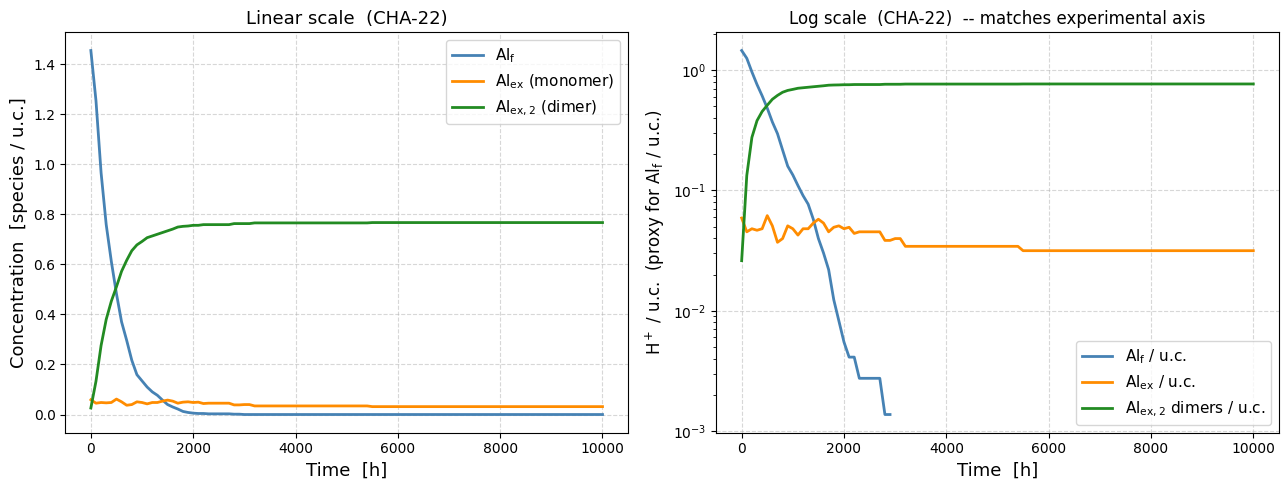

Plot saved as  dealumination_CHA22_profiles.png


In [6]:
profiles = calc.get_species_profiles()   # all in [species / u.c.]

t     = profiles['time']    # hours
alf   = profiles['Al_f']    # Al_f   / u.c.
alex  = profiles['Al_ex']   # Al_ex  / u.c.
alex2 = profiles['Al_ex2']  # dimers / u.c.  =  (NAl_ex2/2) / N_uc

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: linear scale ---------------------------------------------------
ax = axes[0]
ax.plot(t, alf,   color='steelblue',   lw=2, label=r'$\mathrm{Al_f}$')
ax.plot(t, alex,  color='darkorange',  lw=2, label=r'$\mathrm{Al_{ex}}$ (monomer)')
ax.plot(t, alex2, color='forestgreen', lw=2, label=r'$\mathrm{Al_{ex,2}}$ (dimer)')
ax.set_xlabel('Time  [h]', fontsize=13)
ax.set_ylabel('Concentration  [species / u.c.]', fontsize=13)
ax.set_title(f'Linear scale  (CHA-{Si_Al})', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

# --- Right: log-y scale (matches experimental plot style) -----------------
ax = axes[1]
ax.semilogy(t, np.where(alf   > 0, alf,   np.nan), color='steelblue',   lw=2,
            label=r'$\mathrm{Al_f}$ / u.c.')
ax.semilogy(t, np.where(alex  > 0, alex,  np.nan), color='darkorange',  lw=2,
            label=r'$\mathrm{Al_{ex}}$ / u.c.')
ax.semilogy(t, np.where(alex2 > 0, alex2, np.nan), color='forestgreen', lw=2,
            label=r'$\mathrm{Al_{ex,2}}$ dimers / u.c.')
ax.set_xlabel('Time  [h]', fontsize=13)
ax.set_ylabel(r'$\mathrm{H^+}$ / u.c.  (proxy for Al$_\mathrm{f}$ / u.c.)', fontsize=12)
ax.set_title(f'Log scale  (CHA-{Si_Al})  -- matches experimental axis', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'dealumination_CHA{Si_Al}_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Plot saved as  dealumination_CHA{Si_Al}_profiles.png')

## 5. Summary table  [species / u.c.]

In [7]:
print(f"N_uc = {calc.N_uc}  (9x9x9 supercell, hexagonal CHA u.c.)")
print()
print(f"{'Time [h]':>12}  {'Al_f/u.c.':>10}  {'Al_ex/u.c.':>11}  {'Dimers/u.c.':>12}")
print("-" * 52)
step = max(1, len(t) // 20)
for i in range(0, len(t), step):
    print(f"{t[i]:12.3f}  {alf[i]:10.4f}  {alex[i]:11.4f}  {alex2[i]:12.4f}")

N_uc = 729  (9x9x9 supercell, hexagonal CHA u.c.)

    Time [h]   Al_f/u.c.   Al_ex/u.c.   Dimers/u.c.
----------------------------------------------------
       0.000      1.4540       0.0590        0.0261
     500.000      0.4829       0.0617        0.5103
    1000.000      0.1344       0.0480        0.6914
    1500.000      0.0398       0.0576        0.7339
    2000.000      0.0055       0.0480        0.7558
    2500.000      0.0027       0.0453        0.7586
    3000.000      0.0000       0.0398        0.7627
    3500.000      0.0000       0.0343        0.7654
    4000.000      0.0000       0.0343        0.7654
    4500.000      0.0000       0.0343        0.7654
    5000.000      0.0000       0.0343        0.7654
    5500.000      0.0000       0.0316        0.7668
    6000.000      0.0000       0.0316        0.7668
    6500.000      0.0000       0.0316        0.7668
    7000.000      0.0000       0.0316        0.7668
    7500.000      0.0000       0.0316        0.7668
    8000.000